In [1]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MultiLabelBinarizer,  StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
tqdm.pandas(desc="Processing Rows")
import os

import gc
import time
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
import ast
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import SGDClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    r2_score
)
from sklearn.ensemble import ExtraTreesClassifier

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
hf_token = "os.environ['HF_TOKEN']" 

/apps/common/software/Miniforge3/25.11.0-1-jupyter-base/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load in Model

In [2]:
# # model_id = "/common/data/models/meta-llama--Llama-3.2-3B"
# # model_id = "meta-llama/Llama-3.1-8B"
# model_id = "meta-llama/Llama-2-13b-hf"
# print(model_id.split("/")[-1])
# mod=model_id.split("/")[-1]
# from transformers import AutoTokenizer, AutoModelForCausalLM

# hf_token = "os.environ['HF_TOKEN']" 

# tokenizer = AutoTokenizer.from_pretrained(model_id,token=hf_token)
# model = AutoModelForCausalLM.from_pretrained(
#     model_id,
#     torch_dtype=torch.bfloat16,
#     device_map="auto",
#     token=hf_token
# )

In [3]:
# version="semantic"

### Data Reading and formatting

### Test Train split

### Random

pythia-2.8b


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 388/388 [00:07<00:00, 52.56it/s] 


Classes: [1 2 3 4 5 7]
Y_train shape: (100000, 6)
Y_test shape: (20000, 6)
Transformer blocks: 32
Using hidden_state indices: [0, 4, 8, 12, 16, 20, 24, 28, 32]

Extracting train hidden states...


Train: 100%|██████████| 196/196 [02:18<00:00,  1.41it/s]



Extracting test hidden states...


...

Accuracy:  0.5185
F1:        0.6402
Precision: 0.6541
Recall:    0.6301
R2:        0.0277

--- Linear probe on hidden_states[28] ---


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Accuracy:  0.5195
F1:        0.6434
Precision: 0.6524
Recall:    0.6378
R2:        0.0091

--- Linear probe on hidden_states[32] ---


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Accuracy:  0.5214
F1:        0.6451
Precision: 0.6545
Recall:    0.6400
R2:        0.0137
Metrics saved to linear_probe_metrics_pythia-2.8b_rand.txt


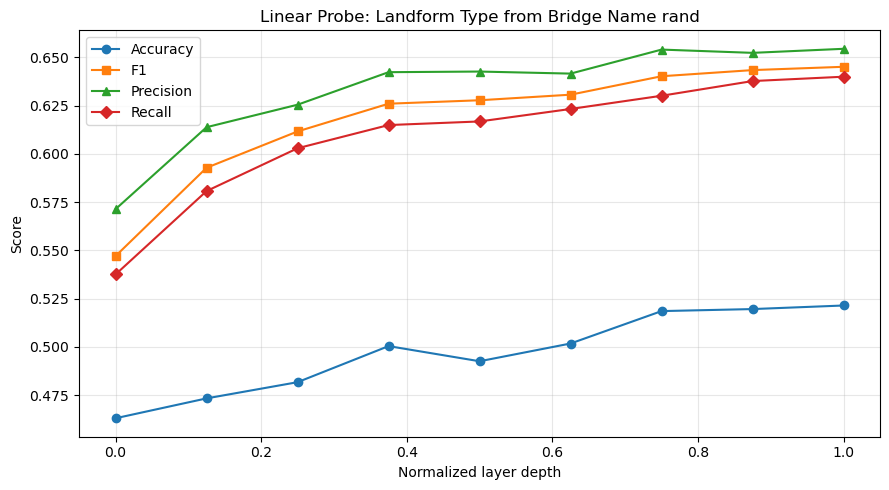

Classes: [1 2 3 4 5 7]
Y_train shape: (100000, 6)
Y_test shape: (20000, 6)
Transformer blocks: 32
Using hidden_state indices: [0, 4, 8, 12, 16, 20, 24, 28, 32]

Extracting train hidden states...


Train: 100%|██████████| 196/196 [02:26<00:00,  1.34it/s]



Extracting test hidden states...


Test: 100%|██████████| 40/40 [00:29<00:00,  1.34it/s]



Extraction time: 4.23 min

--- Linear probe on hidden_states[0] ---


...

Accuracy:  0.5312
F1:        0.6505
Precision: 0.6636
Recall:    0.6403
R2:        0.0519

--- Linear probe on hidden_states[28] ---


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Accuracy:  0.5295
F1:        0.6476
Precision: 0.6599
Recall:    0.6378
R2:        0.0290

--- Linear probe on hidden_states[32] ---


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Accuracy:  0.5253
F1:        0.6544
Precision: 0.6602
Recall:    0.6516
R2:        0.0310
Metrics saved to linear_probe_metrics_pythia-2.8b_question.txt


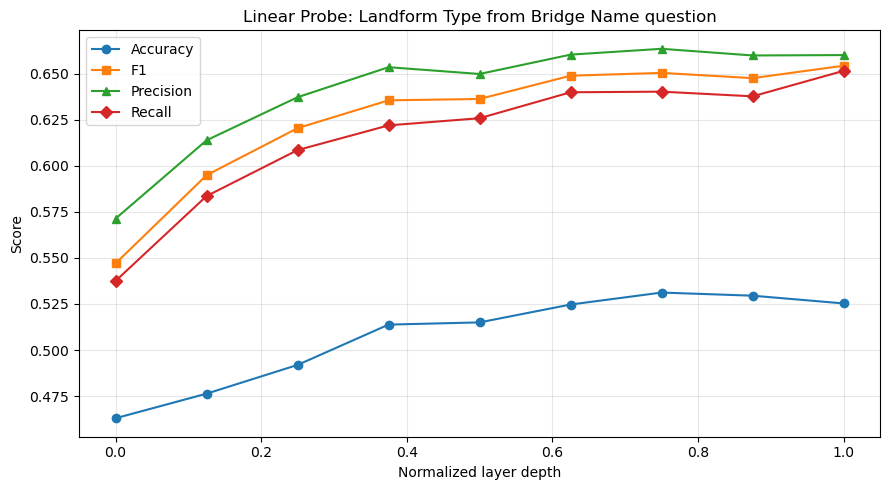

Classes: [1 2 3 4 5 7]
Y_train shape: (100000, 6)
Y_test shape: (20000, 6)
Transformer blocks: 32
Using hidden_state indices: [0, 4, 8, 12, 16, 20, 24, 28, 32]

Extracting train hidden states...


Train: 100%|██████████| 196/196 [02:42<00:00,  1.21it/s]



Extracting test hidden states...


Test: 100%|██████████| 40/40 [00:32<00:00,  1.23it/s]



Extraction time: 3.90 min

--- Linear probe on hidden_states[0] ---


...

Accuracy:  0.5354
F1:        0.6742
Precision: 0.6924
Recall:    0.6575
R2:        -0.0712

--- Linear probe on hidden_states[28] ---


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Accuracy:  0.5315
F1:        0.6704
Precision: 0.7004
Recall:    0.6438
R2:        -0.0766

--- Linear probe on hidden_states[32] ---


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Accuracy:  0.5337
F1:        0.6663
Precision: 0.6713
Recall:    0.6626
R2:        -0.0763
Metrics saved to linear_probe_metrics_pythia-2.8b_semantic.txt


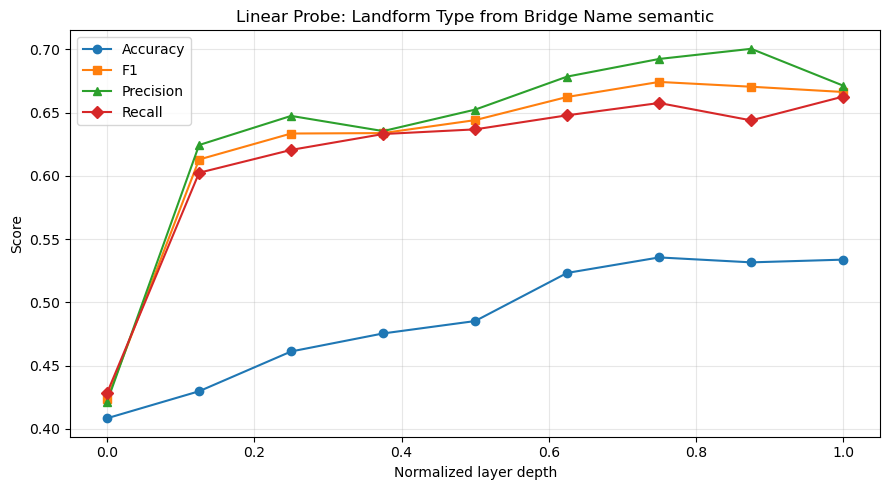

pythia-6.9b


Loading weights: 100%|██████████| 388/388 [00:20<00:00, 19.34it/s]


Classes: [1 2 3 4 5 7]
Y_train shape: (100000, 6)
Y_test shape: (20000, 6)
Transformer blocks: 32
Using hidden_state indices: [0, 4, 8, 12, 16, 20, 24, 28, 32]

Extracting train hidden states...


Train: 100%|██████████| 196/196 [03:37<00:00,  1.11s/it]



Extracting test hidden states...


...

Accuracy:  0.5111
F1:        0.6409
Precision: 0.6476
Recall:    0.6370
R2:        0.0357

--- Linear probe on hidden_states[28] ---


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Accuracy:  0.5234
F1:        0.6442
Precision: 0.6529
Recall:    0.6377
R2:        0.0222

--- Linear probe on hidden_states[32] ---


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Accuracy:  0.5138
F1:        0.6441
Precision: 0.6535
Recall:    0.6384
R2:        0.0120
Metrics saved to linear_probe_metrics_pythia-6.9b_rand.txt


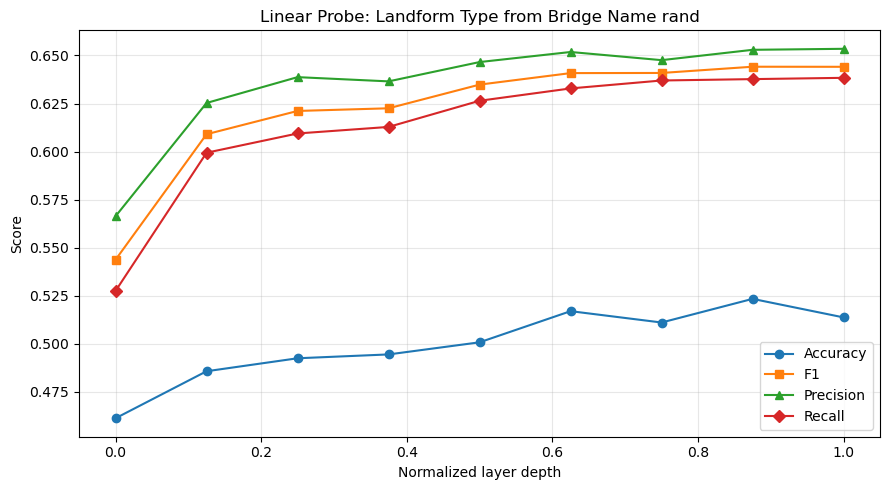

Classes: [1 2 3 4 5 7]
Y_train shape: (100000, 6)
Y_test shape: (20000, 6)
Transformer blocks: 32
Using hidden_state indices: [0, 4, 8, 12, 16, 20, 24, 28, 32]

Extracting train hidden states...


Train: 100%|██████████| 196/196 [04:05<00:00,  1.25s/it]



Extracting test hidden states...


Test: 100%|██████████| 40/40 [00:50<00:00,  1.25s/it]



Extraction time: 6.13 min

--- Linear probe on hidden_states[0] ---


...

Accuracy:  0.5216
F1:        0.6554
Precision: 0.6648
Recall:    0.6476
R2:        0.0679

--- Linear probe on hidden_states[28] ---


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Accuracy:  0.5119
F1:        0.6495
Precision: 0.6571
Recall:    0.6436
R2:        0.0369

--- Linear probe on hidden_states[32] ---


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Accuracy:  0.5179
F1:        0.6492
Precision: 0.6570
Recall:    0.6432
R2:        0.0123
Metrics saved to linear_probe_metrics_pythia-6.9b_question.txt


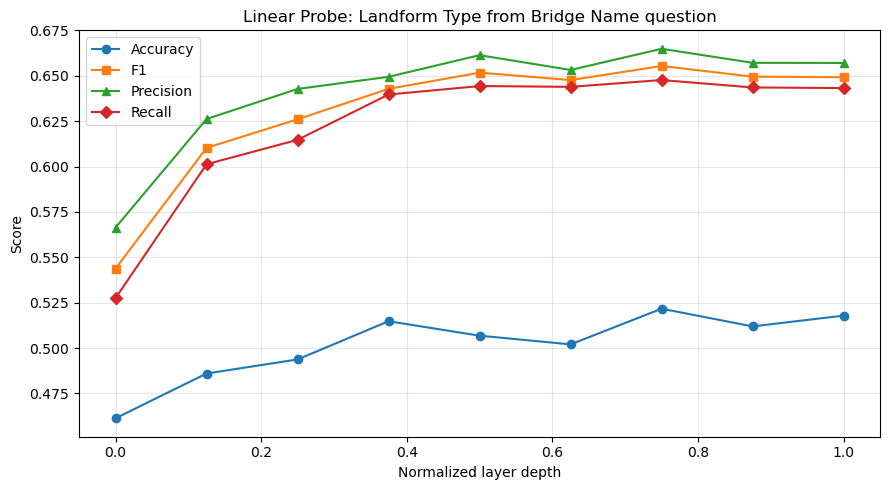

Classes: [1 2 3 4 5 7]
Y_train shape: (100000, 6)
Y_test shape: (20000, 6)
Transformer blocks: 32
Using hidden_state indices: [0, 4, 8, 12, 16, 20, 24, 28, 32]

Extracting train hidden states...


Train: 100%|██████████| 196/196 [04:27<00:00,  1.36s/it]



Extracting test hidden states...


Test: 100%|██████████| 40/40 [00:54<00:00,  1.35s/it]



Extraction time: 5.80 min

--- Linear probe on hidden_states[0] ---


...

Accuracy:  0.5233
F1:        0.6766
Precision: 0.6952
Recall:    0.6599
R2:        -0.0506

--- Linear probe on hidden_states[28] ---


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Accuracy:  0.5168
F1:        0.6726
Precision: 0.6856
Recall:    0.6606
R2:        -0.0727

--- Linear probe on hidden_states[32] ---


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Accuracy:  0.5355
F1:        0.6717
Precision: 0.6849
Recall:    0.6596
R2:        -0.0537
Metrics saved to linear_probe_metrics_pythia-6.9b_semantic.txt


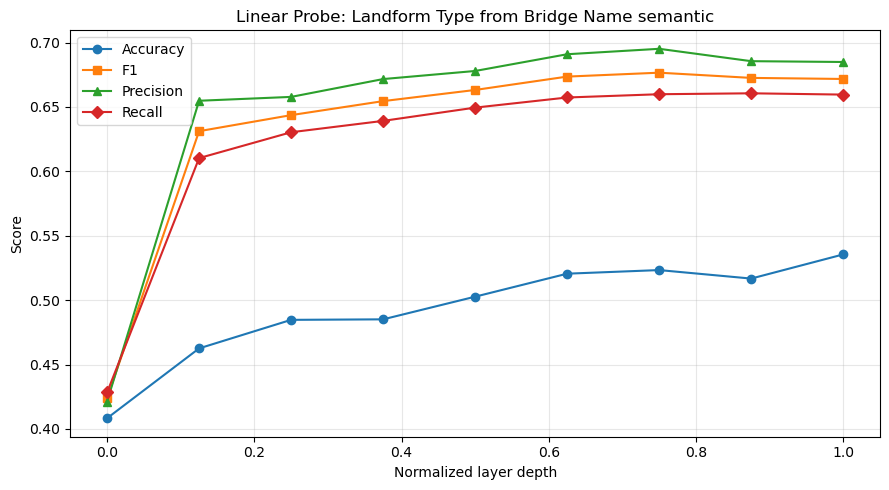

pythia-12b


Loading weights: 100%|██████████| 436/436 [00:01<00:00, 286.86it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


Classes: [1 2 3 4 5 7]
Y_train shape: (100000, 6)
Y_test shape: (20000, 6)
Transformer blocks: 36
Using hidden_state indices: [0, 4, 8, 12, 16, 20, 24, 28, 32, 36]

Extracting train hidden states...


Train: 100%|██████████| 196/196 [13:48<00:00,  4.23s/it]



Extracting test hidden states...


...

Accuracy:  0.5069
F1:        0.6470
Precision: 0.6588
Recall:    0.6378
R2:        0.0141

--- Linear probe on hidden_states[32] ---


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Accuracy:  0.5031
F1:        0.6412
Precision: 0.6515
Recall:    0.6336
R2:        0.0169

--- Linear probe on hidden_states[36] ---


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Accuracy:  0.4978
F1:        0.6430
Precision: 0.6539
Recall:    0.6355
R2:        -0.0071
Metrics saved to linear_probe_metrics_pythia-12b_rand.txt


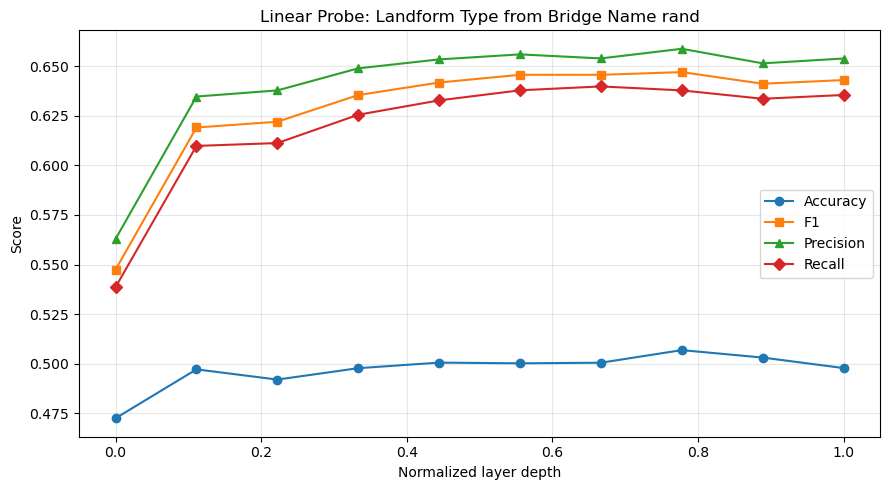

Classes: [1 2 3 4 5 7]
Y_train shape: (100000, 6)
Y_test shape: (20000, 6)
Transformer blocks: 36
Using hidden_state indices: [0, 4, 8, 12, 16, 20, 24, 28, 32, 36]

Extracting train hidden states...


Train: 100%|██████████| 196/196 [14:58<00:00,  4.58s/it]



Extracting test hidden states...


Test: 100%|██████████| 40/40 [03:13<00:00,  4.84s/it]



Extraction time: 23.06 min

--- Linear probe on hidden_states[0] ---


...

Accuracy:  0.5304
F1:        0.6561
Precision: 0.6645
Recall:    0.6493
R2:        0.0288

--- Linear probe on hidden_states[32] ---


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Accuracy:  0.5357
F1:        0.6609
Precision: 0.6628
Recall:    0.6606
R2:        0.0180

--- Linear probe on hidden_states[36] ---


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Accuracy:  0.5362
F1:        0.6621
Precision: 0.6692
Recall:    0.6571
R2:        0.0325
Metrics saved to linear_probe_metrics_pythia-12b_question.txt


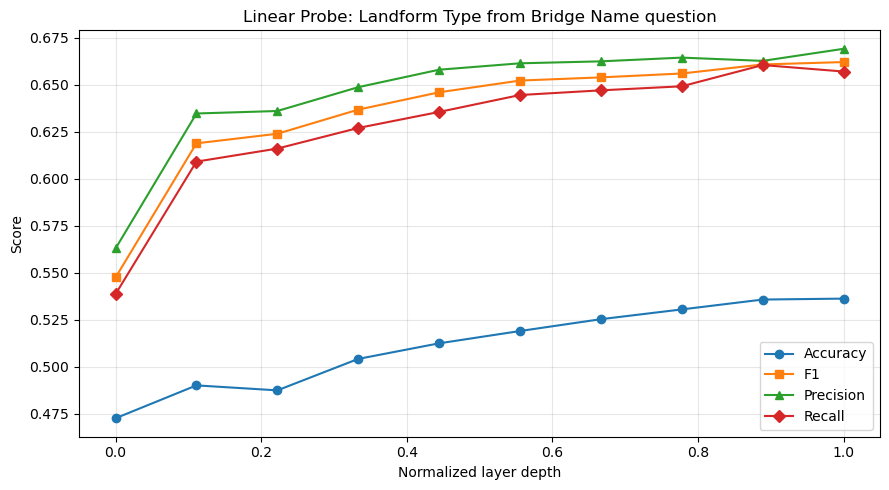

Classes: [1 2 3 4 5 7]
Y_train shape: (100000, 6)
Y_test shape: (20000, 6)
Transformer blocks: 36
Using hidden_state indices: [0, 4, 8, 12, 16, 20, 24, 28, 32, 36]

Extracting train hidden states...


Train: 100%|██████████| 196/196 [15:31<00:00,  4.75s/it]



Extracting test hidden states...


Test: 100%|██████████| 40/40 [03:09<00:00,  4.74s/it]



Extraction time: 19.06 min

--- Linear probe on hidden_states[0] ---


...

Accuracy:  0.5257
F1:        0.6753
Precision: 0.6816
Recall:    0.6692
R2:        -0.0907

--- Linear probe on hidden_states[32] ---


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Accuracy:  0.5248
F1:        0.6752
Precision: 0.6866
Recall:    0.6646
R2:        -0.0768

--- Linear probe on hidden_states[36] ---


/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ravim/.local/lib/python3.14/site-p

Accuracy:  0.5228
F1:        0.6738
Precision: 0.6876
Recall:    0.6614
R2:        -0.0801
Metrics saved to linear_probe_metrics_pythia-12b_semantic.txt


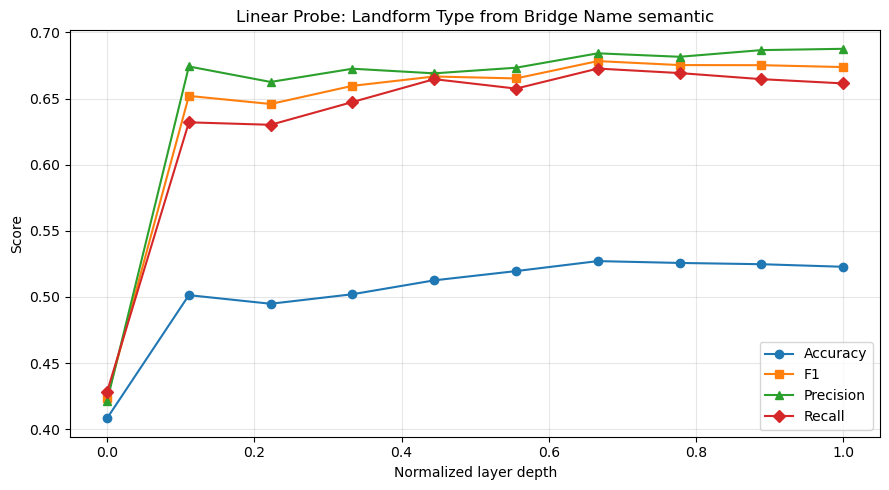

In [4]:
versions=["rand","question","semantic"]
models=[ "EleutherAI/pythia-2.8b", "EleutherAI/pythia-6.9b","EleutherAI/pythia-12b"]
from transformers import AutoTokenizer, AutoModelForCausalLM
model_id = "EleutherAI/pythia-12b"



hf_token = "os.environ['HF_TOKEN']" 
for mod in models:
    model_id = mod
    print(model_id.split("/")[-1])
    mod=model_id.split("/")[-1]
    
    tokenizer = AutoTokenizer.from_pretrained(model_id,token=hf_token)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=torch.bfloat16,
        device_map="auto",
    )

    
    for version in versions:
        if "rand" in version:
            combined_dataset=pd.read_csv("Datasets/rand_token_dataset_sensitivity_dataset.csv")
        if "question" in version:
            combined_dataset=pd.read_csv("Datasets/question_sensitivity_dataset.csv")
        if "semantic" in version:
            combined_dataset=pd.read_csv("Datasets/contradiction_sensitivity_dataset.csv")
        
        def label_to_list(x):
            if isinstance(x, np.ndarray):
                return [int(v) for v in x.tolist()]
        
            if isinstance(x, (list, tuple)):
                return [int(v) for v in x]
        
            if isinstance(x, str):
                x = x.strip()
                if x.startswith("["):
                    return [int(v) for v in ast.literal_eval(x)]
                return [int(float(x))]
        
            return [int(x)]
        
        
        X = combined_dataset["Bridges Full Name"].astype(str)
        y_labels = combined_dataset["Topographic"].apply(label_to_list)
        
        # optional: stratify by exact label-combination string
        y_combo = y_labels.apply(lambda z: tuple(sorted(z)))
        
        X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
            X,
            y_labels,
            test_size=0.20,
            stratify=None,
            random_state=42
        )
        MAX_TRAIN = 100000
        MAX_TEST = 20000
        
        train_combo = y_train_full.apply(lambda z: tuple(sorted(z)))
        test_combo = y_test_full.apply(lambda z: tuple(sorted(z)))
        
        X_train_list, _, y_train_labels, _ = train_test_split(
            X_train_full.tolist(),
            y_train_full.tolist(),
            train_size=min(MAX_TRAIN, len(X_train_full)),
            stratify=None,
            random_state=42
        )
        
        X_test_list, _, y_test_labels, _ = train_test_split(
            X_test_full.tolist(),
            y_test_full.tolist(),
            train_size=min(MAX_TEST, len(X_test_full)),
            stratify=None,
            random_state=42
        )
        
        mlb = MultiLabelBinarizer()
        Y_train = mlb.fit_transform(y_train_labels)
        Y_test = mlb.transform(y_test_labels)
        
        print("Classes:", mlb.classes_)
        print("Y_train shape:", Y_train.shape)
        print("Y_test shape:", Y_test.shape)

        # #####
        
        torch.cuda.empty_cache()
        BATCH_SIZE = 512
        MAX_LEN = 64
        
        num_blocks = len(model.gpt_neox.layers)
        print("Transformer blocks:", num_blocks)
        HIDDEN_STATE_LAYERS = [i for i in range(0,num_blocks+1,4)]
        
        print("Using hidden_state indices:", HIDDEN_STATE_LAYERS)
        
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
        
        tokenizer.padding_side = "right"
        
        model.eval()
        model.config.use_cache = False
        
        if hasattr(model, "gradient_checkpointing_disable"):
            model.gradient_checkpointing_disable()
        
        train_loader = DataLoader(
            X_train_list,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0,
            pin_memory=False
        )
        
        test_loader = DataLoader(
            X_test_list,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0,
            pin_memory=False
        )
        # first extract layers
        def extract_selected_token_states(loader, desc, hidden_state_layers):
            chunks = {l: [] for l in hidden_state_layers}
        
            with torch.inference_mode():
                for batch in tqdm(loader, desc=desc):
                    inputs = tokenizer(
                        list(batch),
                        padding=True,
                        truncation=True,
                        max_length=MAX_LEN,
                        return_tensors="pt"
                    ).to(model.device)
                    lengths = inputs["attention_mask"].sum(dim=1) - 1
                    batch_idx = torch.arange(inputs["input_ids"].shape[0], device=model.device)
        
                    with torch.inference_mode():
                        outputs = model(
                            **inputs,
                            output_hidden_states=True,
                            use_cache=False
                        )
        
                    for l in hidden_state_layers:
                        hs = outputs.hidden_states[l]
                        tok_state = hs[batch_idx, lengths, :]
                        chunks[l].append(tok_state.float().cpu().numpy().astype(np.float32))
        
                    del inputs, outputs, lengths, batch_idx, tok_state
                    gc.collect()
        
            return {l: np.vstack(chunks[l]) for l in hidden_state_layers}
        
        start = time.perf_counter()
        
        print("\nExtracting train hidden states...")
        train_cache = extract_selected_token_states(train_loader, "Train", HIDDEN_STATE_LAYERS)
        
        print("\nExtracting test hidden states...")
        test_cache = extract_selected_token_states(test_loader, "Test", HIDDEN_STATE_LAYERS)
        
        print(f"\nExtraction time: {(time.perf_counter() - start) / 60:.2f} min")
        
        torch.cuda.empty_cache()
        gc.collect()
        
        
        acc_list = []
        f1_list = []
        precision_list = []
        recall_list = []
        r2_list = []
        
        best_score = -1
        best_layer = None
        best_probe = None
        best_pred = None
        
        for hs_idx in HIDDEN_STATE_LAYERS:
            print(f"\n--- Linear probe on hidden_states[{hs_idx}] ---")
        
            Xtr = train_cache[hs_idx]
            Xte = test_cache[hs_idx]
        
            probe = make_pipeline(
                StandardScaler(),
                OneVsRestClassifier(
                    SGDClassifier(
                        loss="log_loss",
                        penalty="l2",
                        alpha=1e-4,
                        max_iter=50,
                        tol=1e-3,
                        random_state=42,
                        early_stopping=False,
                        n_jobs=-1
                    ),
                    n_jobs=-1
                )
            )
        
            probe.fit(Xtr, Y_train)
            pred = probe.predict(Xte)
            
            acc = accuracy_score(Y_test, pred)
            f1 = f1_score(Y_test, pred, average="weighted", zero_division=0)
            precision = precision_score(Y_test, pred, average="weighted", zero_division=0)
            recall = recall_score(Y_test, pred, average="weighted", zero_division=0)
            r2 = r2_score(Y_test, pred)
        
            acc_list.append(acc)
            f1_list.append(f1)
            precision_list.append(precision)
            recall_list.append(recall)
            r2_list.append(r2)
        
            print(f"Accuracy:  {acc:.4f}")
            print(f"F1:        {f1:.4f}")
            print(f"Precision: {precision:.4f}")
            print(f"Recall:    {recall:.4f}")
            print(f"R2:        {r2:.4f}")
        
            if f1 > best_score:
                best_score = f1
                best_layer = hs_idx
                best_probe = probe
                best_pred = pred.copy()
            gc.collect()
        # # Save all lists into one text file
        output_filename = f"linear_probe_metrics_{mod}_{version}.txt"
        
        with open(output_filename, "w") as f:
            f.write(f"Layers:    {HIDDEN_STATE_LAYERS}\n")
            f.write(f"Accuracy:  {acc_list}\n")
            f.write(f"F1:        {f1_list}\n")
            f.write(f"Precision: {precision_list}\n")
            f.write(f"Recall:    {recall_list}\n")
            f.write(f"R2:        {r2_list}\n")
        
        print(f"Metrics saved to {output_filename}")
        depth = np.array(HIDDEN_STATE_LAYERS) / num_blocks
        
        plt.figure(figsize=(9, 5))
        
        plt.plot(depth, acc_list, marker="o", label="Accuracy")
        plt.plot(depth, f1_list, marker="s", label="F1")
        plt.plot(depth, precision_list, marker="^", label="Precision")
        plt.plot(depth, recall_list, marker="D", label="Recall")
        
        plt.xlabel("Normalized layer depth")
        plt.ylabel("Score")
        plt.title(f"Linear Probe: Landform Type from Bridge Name {version}")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"linear_probe_metrics_{mod}_{version}.png")
        plt.show()

In [5]:

# torch.cuda.empty_cache()
# BATCH_SIZE = 512
# MAX_LEN = 64

# num_blocks = len(model.model.layers)
# print("Transformer blocks:", num_blocks)
# HIDDEN_STATE_LAYERS = [i for i in range(0,num_blocks+1,4)]

# print("Using hidden_state indices:", HIDDEN_STATE_LAYERS)

# if tokenizer.pad_token is None:
#     tokenizer.pad_token = tokenizer.eos_token

# tokenizer.padding_side = "right"

# model.eval()
# model.config.use_cache = False

# if hasattr(model, "gradient_checkpointing_disable"):
#     model.gradient_checkpointing_disable()

# train_loader = DataLoader(
#     X_train_list,
#     batch_size=BATCH_SIZE,
#     shuffle=False,
#     num_workers=0,
#     pin_memory=False
# )

# test_loader = DataLoader(
#     X_test_list,
#     batch_size=BATCH_SIZE,
#     shuffle=False,
#     num_workers=0,
#     pin_memory=False
# )
# # first extract layers
# def extract_selected_token_states(loader, desc, hidden_state_layers):
#     chunks = {l: [] for l in hidden_state_layers}

#     with torch.inference_mode():
#         for batch in tqdm(loader, desc=desc):
#             inputs = tokenizer(
#                 list(batch),
#                 padding=True,
#                 truncation=True,
#                 max_length=MAX_LEN,
#                 return_tensors="pt"
#             ).to(model.device)
#             lengths = inputs["attention_mask"].sum(dim=1) - 1
#             batch_idx = torch.arange(inputs["input_ids"].shape[0], device=model.device)

#             with torch.inference_mode():
#                 outputs = model(
#                     **inputs,
#                     output_hidden_states=True,
#                     use_cache=False
#                 )

#             for l in hidden_state_layers:
#                 hs = outputs.hidden_states[l]
#                 tok_state = hs[batch_idx, lengths, :]
#                 chunks[l].append(tok_state.float().cpu().numpy().astype(np.float32))

#             del inputs, outputs, lengths, batch_idx, tok_state
#             gc.collect()

#     return {l: np.vstack(chunks[l]) for l in hidden_state_layers}

# start = time.perf_counter()

# print("\nExtracting train hidden states...")
# train_cache = extract_selected_token_states(train_loader, "Train", HIDDEN_STATE_LAYERS)

# print("\nExtracting test hidden states...")
# test_cache = extract_selected_token_states(test_loader, "Test", HIDDEN_STATE_LAYERS)

# print(f"\nExtraction time: {(time.perf_counter() - start) / 60:.2f} min")

# torch.cuda.empty_cache()
# gc.collect()


# acc_list = []
# f1_list = []
# precision_list = []
# recall_list = []
# r2_list = []

# best_score = -1
# best_layer = None
# best_probe = None
# best_pred = None

# for hs_idx in HIDDEN_STATE_LAYERS:
#     print(f"\n--- Linear probe on hidden_states[{hs_idx}] ---")

#     Xtr = train_cache[hs_idx]
#     Xte = test_cache[hs_idx]

#     probe = make_pipeline(
#         StandardScaler(),
#         OneVsRestClassifier(
#             SGDClassifier(
#                 loss="log_loss",
#                 penalty="l2",
#                 alpha=1e-4,
#                 max_iter=50,
#                 tol=1e-3,
#                 random_state=42,
#                 early_stopping=False,
#                 n_jobs=-1
#             ),
#             n_jobs=-1
#         )
#     )

#     probe.fit(Xtr, Y_train)
#     pred = probe.predict(Xte)
    
#     acc = accuracy_score(Y_test, pred)
#     f1 = f1_score(Y_test, pred, average="weighted", zero_division=0)
#     precision = precision_score(Y_test, pred, average="weighted", zero_division=0)
#     recall = recall_score(Y_test, pred, average="weighted", zero_division=0)
#     r2 = r2_score(Y_test, pred)

#     acc_list.append(acc)
#     f1_list.append(f1)
#     precision_list.append(precision)
#     recall_list.append(recall)
#     r2_list.append(r2)

#     print(f"Accuracy:  {acc:.4f}")
#     print(f"F1:        {f1:.4f}")
#     print(f"Precision: {precision:.4f}")
#     print(f"Recall:    {recall:.4f}")
#     print(f"R2:        {r2:.4f}")

#     if f1 > best_score:
#         best_score = f1
#         best_layer = hs_idx
#         best_probe = probe
#         best_pred = pred.copy()
#     gc.collect()
# # # Save all lists into one text file
# output_filename = f"linear_probe_metrics_{mod}_{version}.txt"

# with open(output_filename, "w") as f:
#     f.write(f"Layers:    {HIDDEN_STATE_LAYERS}\n")
#     f.write(f"Accuracy:  {acc_list}\n")
#     f.write(f"F1:        {f1_list}\n")
#     f.write(f"Precision: {precision_list}\n")
#     f.write(f"Recall:    {recall_list}\n")
#     f.write(f"R2:        {r2_list}\n")

# print(f"Metrics saved to {output_filename}")
# depth = np.array(HIDDEN_STATE_LAYERS) / num_blocks

# plt.figure(figsize=(9, 5))

# plt.plot(depth, acc_list, marker="o", label="Accuracy")
# plt.plot(depth, f1_list, marker="s", label="F1")
# plt.plot(depth, precision_list, marker="^", label="Precision")
# plt.plot(depth, recall_list, marker="D", label="Recall")

# plt.xlabel("Normalized layer depth")
# plt.ylabel("Score")
# plt.title(f"Linear Probe: Landform Type from Bridge Name {version}")
# plt.grid(True, alpha=0.3)
# plt.legend()
# plt.tight_layout()
# plt.show()